# Stage 15 — Interactive risk map

Relative karst risk across Tasmania (DEA 2020). Click a karst system for its name, category, exposure, connectivity class (D8 routing) and mean risk. Use the buttons to jump to Mole Creek and the layer button to change the base map. Grey land has no karst mapped.

In [1]:
# --- Set-up: imports and helpers ---
from pathlib import Path
import os, sys, io, json, base64, tempfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.transform import array_bounds
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from PIL import Image
import folium

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_karst_susceptibility, add_connectivity, add_connectivity_d8, classify_fixed, RISK_EDGES, RISK_LABELS
from mapping import RISK_COLOURS

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"
OUT_HTML = Path("..") / "figures" / "interactive_risk_map.html"

def hex_colour(rgba):
    r, g, b = (int(round(c * 255)) for c in rgba[:3])
    return f"#{r:02x}{g:02x}{b:02x}"

def round_coords(obj, nd=4):
    if isinstance(obj, float):
        return round(obj, nd)
    if isinstance(obj, (list, tuple)):
        return [round_coords(o, nd) for o in obj]
    return obj

# --- 15.1 The risk surface as a map overlay: class, colour and reproject the 100 m raster to Web Mercator so it lines up with the base map ---
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    risk = src.read(1).astype("float32"); nodata = src.nodata
    src_crs, src_transform = src.crs, src.transform
    src_bounds = src.bounds
valid = risk != nodata
risk_class, edges, labels = classify_fixed(np.where(valid, risk, 0.0), valid)   # 0 = None, 1-5 = Very Low .. Very High

height, width = risk_class.shape
dst_transform, dst_w, dst_h = calculate_default_transform(src_crs, "EPSG:3857", width, height, *src_bounds)
class_merc = np.full((dst_h, dst_w), 255, dtype="uint8")
reproject(risk_class, class_merc, src_transform=src_transform, src_crs=src_crs,
          dst_transform=dst_transform, dst_crs="EPSG:3857", src_nodata=255, dst_nodata=255,
          resampling=Resampling.nearest)

rgba = np.zeros((dst_h, dst_w, 4), dtype="uint8")
for k in range(1, 6):
    rgba[class_merc == k] = [*(int(round(c * 255)) for c in RISK_COLOURS[k][:3]), 235]
png_path = Path(tempfile.gettempdir()) / "risk_overlay.png"
Image.fromarray(rgba, "RGBA").save(png_path, optimize=True)

west, south, east, north = transform_bounds("EPSG:3857", "EPSG:4326", *array_bounds(dst_h, dst_w, dst_transform))
overlay_bounds = [[south, west], [north, east]]
print(f"Overlay: {dst_w} x {dst_h} px, {png_path.stat().st_size / 1e6:.2f} MB; bounds {overlay_bounds}")
print("Cells per class:", {labels[k]: int((risk_class == k).sum()) for k in range(6)})

# --- 15.2 Karst systems with their mean risk (pooled over each named system, as in Stages 6 to 10) ---
karst = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst = karst[karst.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst); add_connectivity(karst)
add_connectivity_d8(karst, outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv", scheme="decades")
karst = karst[karst["karst_intensity"] > 0].copy()

system_risk = {}
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    for name, group in karst.dropna(subset=["KNAME"]).groupby("KNAME"):
        img, _ = mask(src, list(group.geometry), crop=True, nodata=nodata)
        v = img[0]; v = v[v != nodata]
        system_risk[name] = (float(v.mean()), int(len(v))) if len(v) else (np.nan, 0)

karst["Mean risk"] = karst["KNAME"].map(lambda n: round(system_risk.get(n, (np.nan, 0))[0], 3))
karst["System"] = karst["KNAME"].fillna("Unnamed")
karst["Karst category"] = karst["KCATEGORY"]
karst["Exposure"] = karst["exposure_type"]
karst["Connectivity class (D8, 1-5)"] = karst["d8_class"].map(lambda v: "too small to route" if np.isnan(v) else str(int(v)))
keep = ["System", "Karst category", "Exposure", "Connectivity class (D8, 1-5)", "Mean risk"]

karst_ll = karst[keep + ["geometry"]].copy()
karst_ll["geometry"] = karst_ll.geometry.simplify(100)
karst_ll = karst_ll.to_crs("EPSG:4326")
karst_json = json.loads(karst_ll.to_json(drop_id=True))
for f in karst_json["features"]:
    f["geometry"]["coordinates"] = round_coords(f["geometry"]["coordinates"], 4)
print(f"Karst systems on the map: {len(karst_ll)} polygons, {len(json.dumps(karst_json)) / 1e6:.2f} MB of GeoJSON")

tas = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
tas["geometry"] = tas.geometry.simplify(150)
tas_json = json.loads(tas.to_crs("EPSG:4326")[["geometry"]].to_json(drop_id=True))
for f in tas_json["features"]:
    f["geometry"]["coordinates"] = round_coords(f["geometry"]["coordinates"], 4)
print(f"Tasmania outline: {len(json.dumps(tas_json)) / 1e6:.2f} MB of GeoJSON")

# --- 15.3 Assemble the map: land in grey below the risk image, outlines above it, legend, zoom buttons ---
# One look for both classes: "no karst mapped" is a solid grey class, and every outline (karst and land) is the same.
NO_KARST_GREY = "#c9c9c9"
NO_KARST_OPACITY = 0.8
OUTLINE = "#555555"

fig = folium.Figure(width="100%", height="720px")
m = folium.Map(location=[-42.05, 146.6], zoom_start=7, tiles=None, control_scale=True, prefer_canvas=True).add_to(fig)
folium.TileLayer("https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
                 attr="Tiles &copy; Esri", name="Esri World Topo", max_zoom=17, show=True).add_to(m)
folium.TileLayer("https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
                 attr="Tiles &copy; Esri", name="Light grey base map", max_zoom=16, show=False).add_to(m)

# Own pane below the risk image (the overlay pane is 400), so the grey never tints the risk colours.
folium.map.CustomPane("land", z_index=350, pointer_events=False).add_to(m)
land = folium.FeatureGroup(name="Tasmania land (grey = no karst mapped)", show=True)
folium.GeoJson(tas_json, style_function=lambda f: {"fillColor": NO_KARST_GREY, "fillOpacity": NO_KARST_OPACITY, "color": OUTLINE, "weight": 0.7},
               interactive=False, pane="land").add_to(land)
land.add_to(m)

folium.raster_layers.ImageOverlay(image=str(png_path), bounds=overlay_bounds, opacity=1.0, interactive=False,
                                  name="Relative karst risk (DEA 2020)", zindex=3).add_to(m)

systems = folium.FeatureGroup(name="Karst systems (click for details)", show=True)
folium.GeoJson(
    karst_json,
    style_function=lambda f: {"color": OUTLINE, "weight": 0.7, "fillColor": OUTLINE, "fillOpacity": 0.02},
    highlight_function=lambda f: {"weight": 2.2, "color": "#000000", "fillOpacity": 0.12},
    tooltip=folium.GeoJsonTooltip(fields=["System"], aliases=[""], sticky=True),
    popup=folium.GeoJsonPopup(fields=keep, aliases=["System", "Karst category (A highest)", "Exposure", "Connectivity class (D8, 1-5)", "Mean risk (0-1)"], max_width=280),
).add_to(systems)
systems.add_to(m)

folium.LayerControl(collapsed=True, position="topright").add_to(m)

rows = "".join(
    f'<div><span style="display:inline-block;width:14px;height:14px;margin-right:6px;vertical-align:middle;background:{hex_colour(RISK_COLOURS[k])};border:1px solid #777"></span>'
    f'{labels[k]} ({edges[k - 2] if k > 1 else 0:g}-{edges[k - 1] if k <= len(edges) else 1:g})</div>'
    for k in range(1, 6))
legend = f'''
<div style="position:fixed;bottom:26px;left:12px;z-index:9999;background:rgba(255,255,255,0.94);padding:9px 11px;border:1px solid #888;border-radius:4px;font:12px/1.45 Helvetica,Arial,sans-serif;max-width:230px;box-shadow:0 1px 4px rgba(0,0,0,0.3)">
<div style="font-weight:700;margin-bottom:4px">Relative karst risk, 2020</div>
{rows}
<div style="margin-top:4px"><span style="display:inline-block;width:14px;height:14px;margin-right:6px;vertical-align:middle;background:{NO_KARST_GREY};opacity:{NO_KARST_OPACITY};border:1px solid #777"></span>No karst mapped (not &ldquo;low risk&rdquo;)</div>
</div>'''
m.get_root().html.add_child(folium.Element(legend))

mc = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg").to_crs("EPSG:4326").total_bounds
js = f'''
// run after the page (and so the map object) exists
window.addEventListener("load", function() {{
var MAP_ = {m.get_name()};
function addBtn(label, title, bounds) {{
  var c = L.control({{position: "topleft"}});
  c.onAdd = function() {{
    var d = L.DomUtil.create("div", "leaflet-bar");
    d.innerHTML = '<a href="#" title="' + title + '" style="width:auto;padding:0 9px;font:12px/30px Helvetica,Arial,sans-serif;color:#222">' + label + '</a>';
    d.onclick = function(e) {{ L.DomEvent.preventDefault(e); MAP_.fitBounds(bounds); }};
    return d;
  }};
  c.addTo(MAP_);
}}
addBtn("Tasmania", "Zoom to all of Tasmania", [[{south}, {west}], [{north}, {east}]]);
addBtn("Mole Creek", "Zoom to the Mole Creek study area", [[{mc[1]}, {mc[0]}], [{mc[3]}, {mc[2]}]]);
}});
'''
m.get_root().script.add_child(folium.Element(js))
m.fit_bounds([[-43.8, 144.0], [-39.6, 148.5]])

OUT_HTML.parent.mkdir(exist_ok=True)
m.save(str(OUT_HTML))
print(f"Saved {OUT_HTML.resolve()} ({OUT_HTML.stat().st_size / 1e6:.2f} MB)")


Overlay: 4121 x 5076 px, 0.27 MB; bounds [[-43.71371800207102, 143.61502893641293], [-39.14886972159553, 148.5613818816329]]
Cells per class: {'None': 6386892, 'Very Low': 85012, 'Low': 134952, 'Moderate': 140007, 'High': 37111, 'Very High': 12921}


Karst systems on the map: 1677 polygons, 0.78 MB of GeoJSON


Tasmania outline: 0.35 MB of GeoJSON
Saved /Users/maggie/Downloads/AT3_Group3_2026/figures/interactive_risk_map.html (1.53 MB)



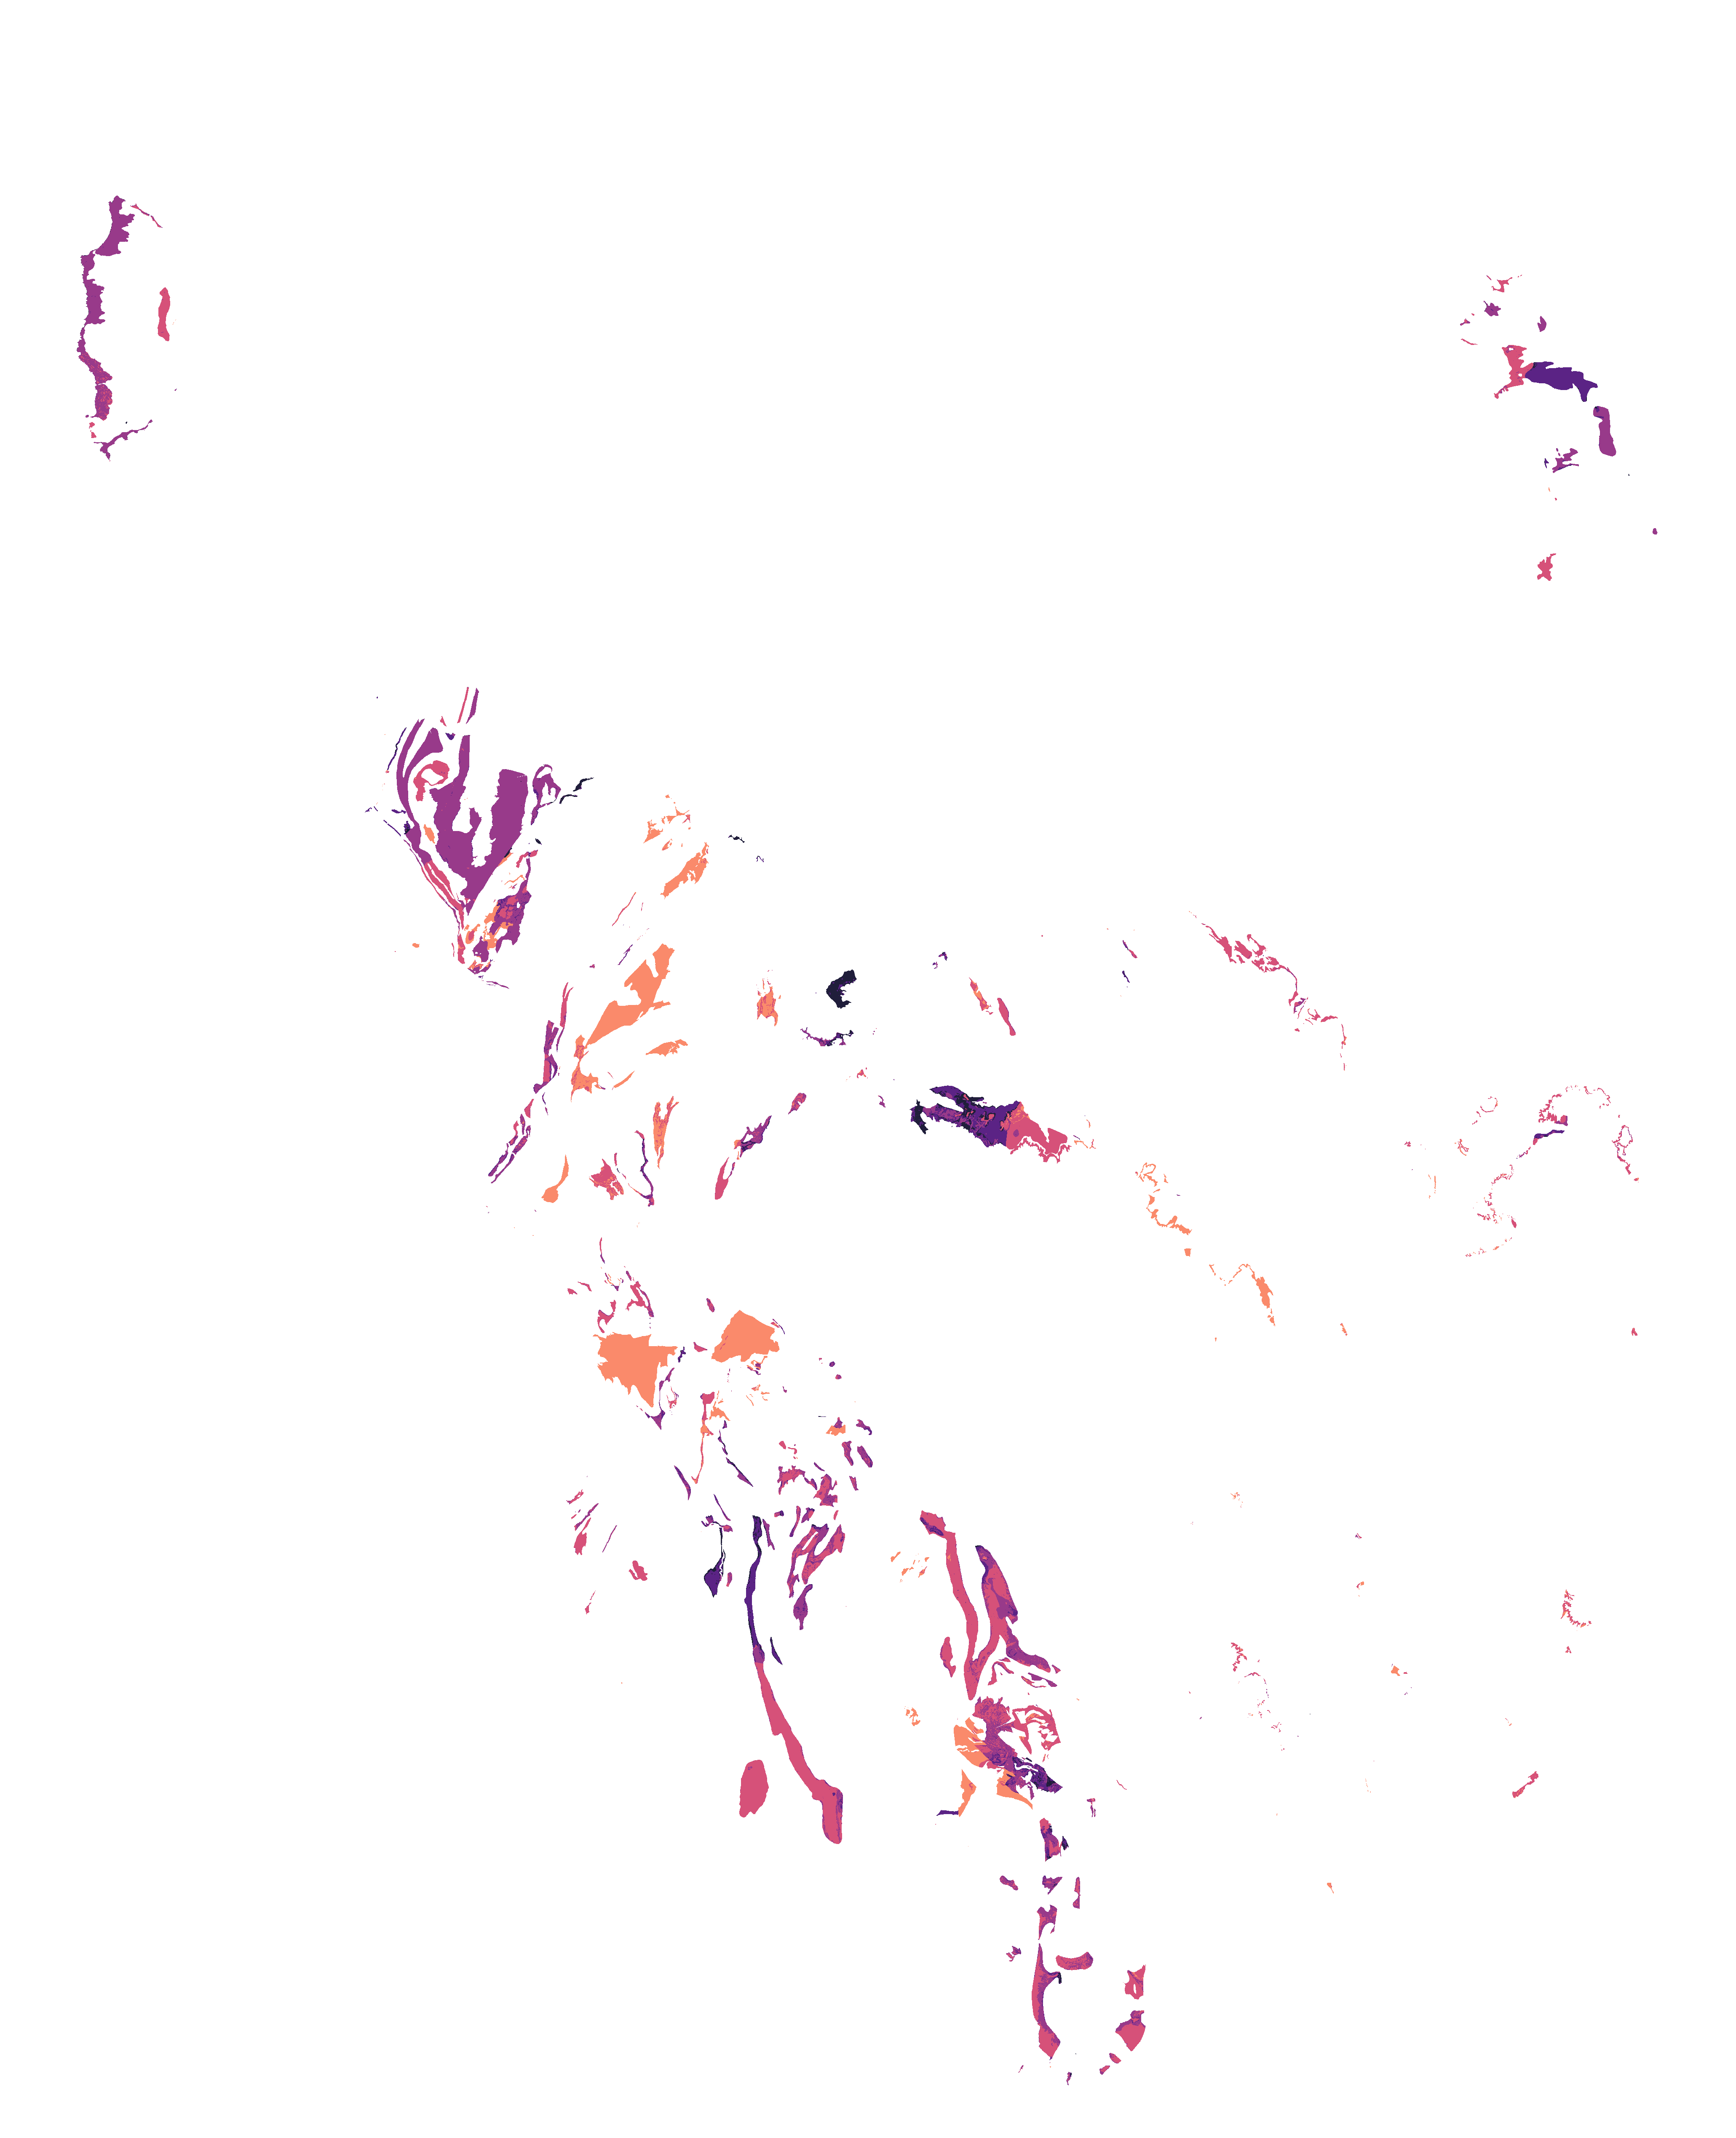

In [2]:
fig

## Notes

- **Layers:** the statewide 100 m risk surface in the same fixed classes and colours as the book maps (0.05-wide steps up to 0.20) (cells with no risk are transparent); the outline of every mapped karst system, with mean risk pooled over the whole named system; and the rest of the land in grey, with no karst mapped.
- **Where it lives:** the map is a single folium (Leaflet) page, also saved as `figures/interactive_risk_map.html`. The book build does not run notebooks, so re-run this notebook after any change to the risk raster. The base-map tiles need an internet connection.
- **Method:** the raster is reprojected to Web Mercator so it lines up with the base map, and the grey land sits in its own layer below the risk image so it never tints the risk colours. The code is under the *Source* bar above the map.

## Land-use pressure: DEA 2021 against LIST 2021

Drag the divider to compare the two land-use layers at Mole Creek for 2021: DEA land cover (left) and the LIST land-use matrix (right). Each layer is scored on its own scale (DEA 0 to 3, LIST 0 to 10) and drawn as a share of its own maximum, so darker means higher pressure within that layer. The differences show what each data source can see: LIST separates plantation forestry, irrigated pasture and intensive uses that DEA counts as natural or cultivated cover. Outlines are the Mole Creek karst.

In [3]:
import matplotlib
from karst import in_mole_creek_focus
magma_r = matplotlib.colormaps["magma_r"]

def pressure_overlay(arr, max_score, name):
    """Mole Creek pressure (a score raster on the 25 m grid) as a Web Mercator PNG overlay, drawn as a share of `max_score`."""
    with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
        crs, tf, bnds, w, h = src.crs, src.transform, src.bounds, src.width, src.height
    dst_tf, dw, dh = calculate_default_transform(crs, "EPSG:3857", w, h, *bnds)
    merc = np.full((dh, dw), -1.0, dtype="float32")
    reproject(arr.astype("float32"), merc, src_transform=tf, src_crs=crs, dst_transform=dst_tf, dst_crs="EPSG:3857",
              src_nodata=-1, dst_nodata=-1, resampling=Resampling.nearest)
    share = np.where(merc > 0, merc / max_score, 0.0).clip(0, 1)
    rgba = np.zeros((dh, dw, 4), dtype="uint8")
    colours = (magma_r(0.08 + 0.84 * share)[..., :3] * 255).round().astype("uint8")
    rgba[..., :3] = colours
    rgba[..., 3] = np.where(merc > 0, (60 + 175 * share).astype("uint8"), 0)
    path = Path(tempfile.gettempdir()) / f"pressure_{name}.png"
    Image.fromarray(rgba, "RGBA").save(path, optimize=True)
    west, south, east, north = transform_bounds("EPSG:3857", "EPSG:4326", *array_bounds(dh, dw, dst_tf))
    return path, [[south, west], [north, east]]

from landuse import fetch_landuse_pressure
from landuse_list import MATRIX, load_list_landuse, pressure_raster

with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    mc_shape, mc_transform, mc_bounds_t = (src.height, src.width), src.transform, src.bounds
mc_box = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg").to_crs("EPSG:4326").total_bounds.tolist()
dea_2021 = fetch_landuse_pressure(mc_box, 2021, outpath / "dem_mc_EPSG7855.tif", cache_dir=inpath / "DEA_Land_Cover_Cache").astype(float)
dea_2021 = np.where(dea_2021 == 255, -1.0, dea_2021)
lu_mc = load_list_landuse(inpath / "LIST_LAND_USE_2021_STATEWIDE" / "list_land_use_2021_statewide.shp", "EPSG:7855", bounds_target=tuple(mc_bounds_t))
list_2021 = pressure_raster(lu_mc, MATRIX, mc_shape, mc_transform).astype(float)

png_dea, pbounds = pressure_overlay(dea_2021, 3.0, "dea_2021")
png_list, _ = pressure_overlay(list_2021, float(max(MATRIX.values())), "list_2021")

mck = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
mck = mck[mck.geom_type.isin(["Polygon", "MultiPolygon"]) & (mck["karst_intensity"] > 0) & in_mole_creek_focus(mck)].copy()
mck["geometry"] = mck.geometry.simplify(30)
outline_json = json.loads(mck[["geometry"]].to_crs("EPSG:4326").to_json(drop_id=True))
for f in outline_json["features"]:
    f["geometry"]["coordinates"] = round_coords(f["geometry"]["coordinates"], 5)

fig2 = folium.Figure(width="100%", height="400px")
m2 = folium.Map(tiles=None, control_scale=True, prefer_canvas=True).add_to(fig2)
folium.TileLayer("https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
                 attr="Tiles &copy; Esri", name="Esri World Topo", max_zoom=17).add_to(m2)
for name, z in [("pdea", 450), ("plist", 451), ("outline", 460)]:
    folium.map.CustomPane(name, z_index=z, pointer_events=False).add_to(m2)
folium.raster_layers.ImageOverlay(image=str(png_dea), bounds=pbounds, interactive=False, pane="pdea").add_to(m2)
folium.raster_layers.ImageOverlay(image=str(png_list), bounds=pbounds, interactive=False, pane="plist").add_to(m2)
folium.GeoJson(outline_json, style_function=lambda f: {"color": "#222222", "weight": 1.0, "fillOpacity": 0},
               interactive=False, pane="outline").add_to(m2)
kb = mck.to_crs("EPSG:4326").total_bounds   # start on the Mole Creek karst, not the whole buffer
m2.fit_bounds([[kb[1] - 0.02, kb[0] - 0.02], [kb[3] + 0.02, kb[2] + 0.02]])

def swatch(level, alpha, label):
    r, g, b = (int(round(v * 255)) for v in magma_r(0.08 + 0.84 * level)[:3])
    return (f'<div><span style="display:inline-block;width:14px;height:14px;margin-right:6px;vertical-align:middle;'
            f'background:rgba({r},{g},{b},{alpha});border:1px solid #777"></span>{label}</div>')
legend2 = ('<div style="position:absolute;bottom:26px;left:12px;z-index:1000;background:rgba(255,255,255,0.94);padding:8px 10px;'
           'border:1px solid #888;border-radius:4px;font:12px/1.45 Helvetica,Arial,sans-serif;box-shadow:0 1px 4px rgba(0,0,0,0.3)">'
           '<div style="font-weight:700;margin-bottom:3px">Land-use pressure</div>'
           + swatch(1.0, 0.9, "Highest in the layer") + swatch(0.55, 0.65, "Middle") + swatch(0.1, 0.35, "Lowest, above zero")
           + '<div style="margin-top:3px;color:#555">Share of each layer\'s own maximum<br>Outline: Mole Creek karst</div></div>')
m2.get_root().html.add_child(folium.Element(legend2))

js2 = f"""
window.addEventListener("load", function() {{
  var map = {m2.get_name()};
  var left = map.getPane("pdea"), right = map.getPane("plist");
  var frac = 0.5, dragging = false, box = map.getContainer();
  var div = document.createElement("div");
  div.style.cssText = "position:absolute;top:0;bottom:0;width:4px;margin-left:-2px;background:#fff;box-shadow:0 0 4px rgba(0,0,0,.6);z-index:1000;cursor:ew-resize;touch-action:none";
  div.innerHTML = '<div style="position:absolute;top:50%;left:50%;width:34px;height:34px;margin:-17px 0 0 -17px;border-radius:50%;background:#fff;border:2px solid #444;box-shadow:0 0 5px rgba(0,0,0,.5);font:bold 15px/30px Helvetica,Arial,sans-serif;text-align:center;color:#333">&#8596;</div>';
  box.appendChild(div);
  L.DomEvent.disableClickPropagation(div);
  function label(text, side) {{
    var d = document.createElement("div"); d.textContent = text;
    d.style.cssText = "position:absolute;top:10px;" + side + ":" + (side === "left" ? "58px" : "12px") + ";z-index:1000;background:rgba(255,255,255,.92);padding:3px 10px;border-radius:3px;font:700 14px Helvetica,Arial,sans-serif;box-shadow:0 1px 3px rgba(0,0,0,.4)";
    box.appendChild(d);
  }}
  label("DEA 2021", "left"); label("LIST 2021", "right");
  function update() {{
    var size = map.getSize(), x = Math.round(frac * size.x);
    var nw = map.containerPointToLayerPoint([0, 0]), se = map.containerPointToLayerPoint(size), mid = map.containerPointToLayerPoint([x, 0]);
    left.style.clip = "rect(" + nw.y + "px," + mid.x + "px," + se.y + "px," + nw.x + "px)";
    right.style.clip = "rect(" + nw.y + "px," + se.x + "px," + se.y + "px," + mid.x + "px)";
    div.style.left = x + "px";
  }}
  function move(clientX) {{
    var r = box.getBoundingClientRect();
    frac = Math.min(1, Math.max(0, (clientX - r.left) / r.width)); update();
  }}
  div.addEventListener("mousedown", function(e) {{ dragging = true; map.dragging.disable(); e.preventDefault(); }});
  div.addEventListener("touchstart", function(e) {{ dragging = true; map.dragging.disable(); }}, {{passive: true}});
  document.addEventListener("mousemove", function(e) {{ if (dragging) move(e.clientX); }});
  document.addEventListener("touchmove", function(e) {{ if (dragging) move(e.touches[0].clientX); }}, {{passive: true}});
  function stop() {{ if (dragging) {{ dragging = false; map.dragging.enable(); }} }}
  document.addEventListener("mouseup", stop); document.addEventListener("touchend", stop);
  map.on("move zoom resize viewreset", update);
  update();
}});
"""
m2.get_root().script.add_child(folium.Element(js2))
print(f"Pressure overlays: {png_dea.stat().st_size / 1e3:.0f} KB (DEA 2021), {png_list.stat().st_size / 1e3:.0f} KB (LIST 2021)")

Pressure overlays: 194 KB (DEA 2021), 260 KB (LIST 2021)



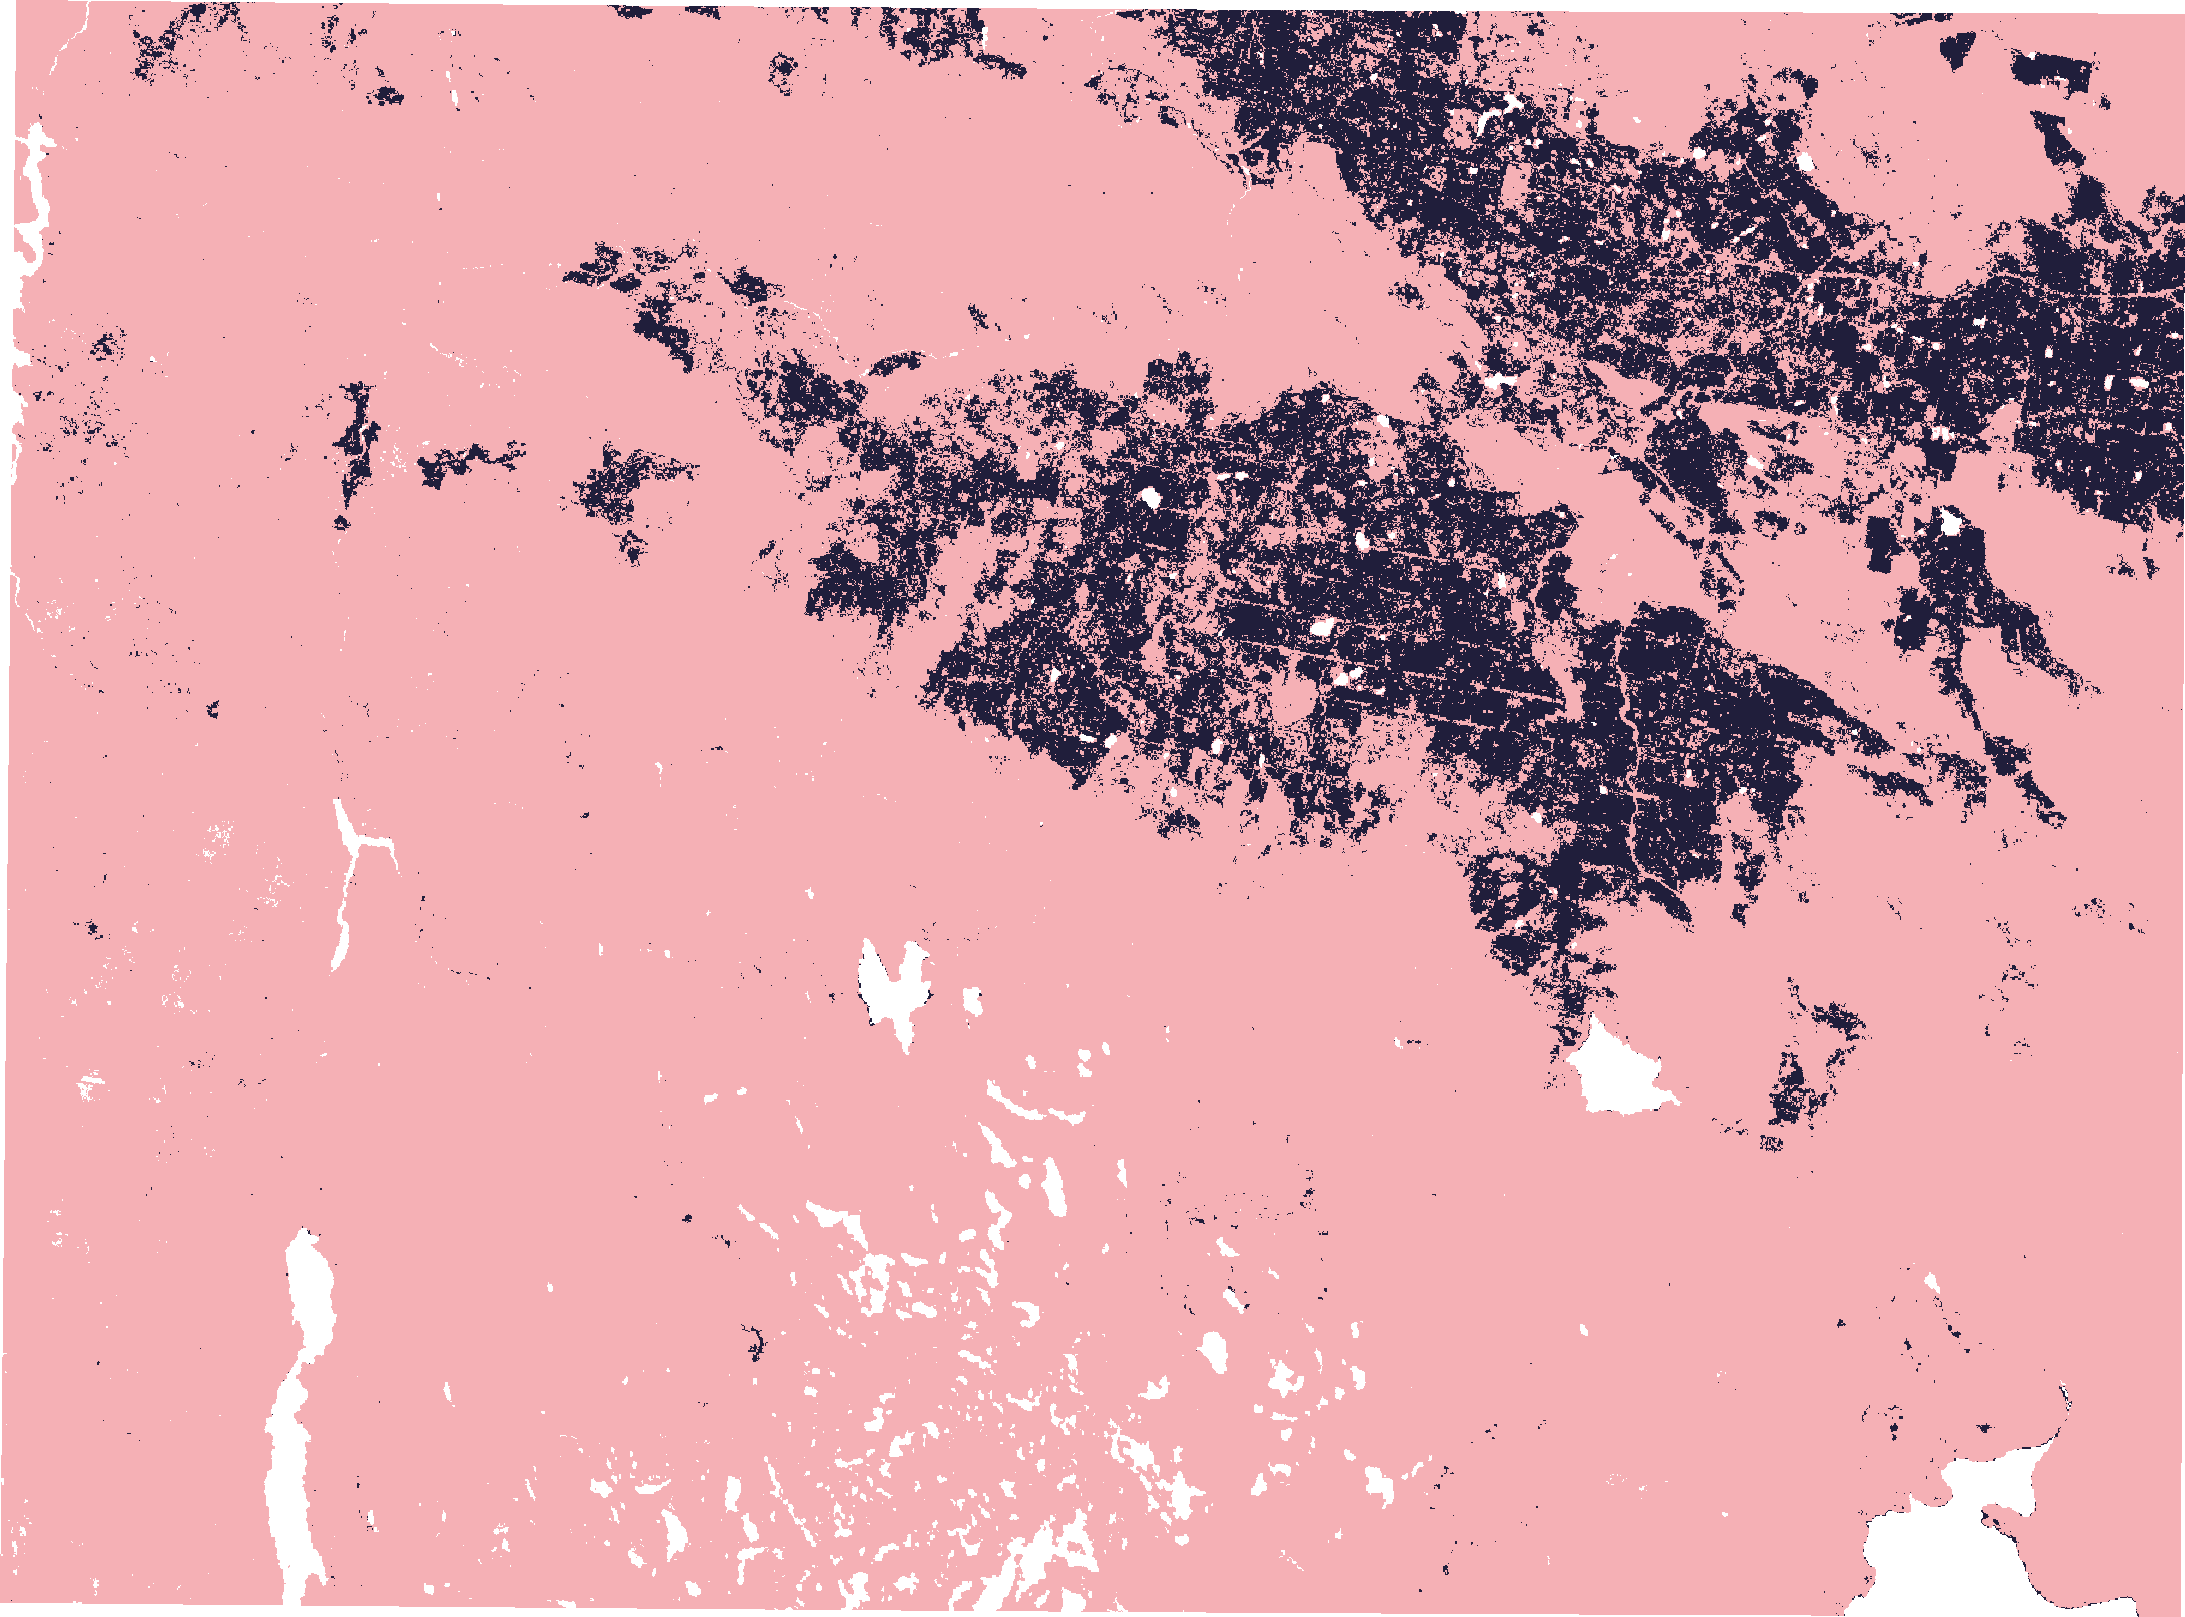
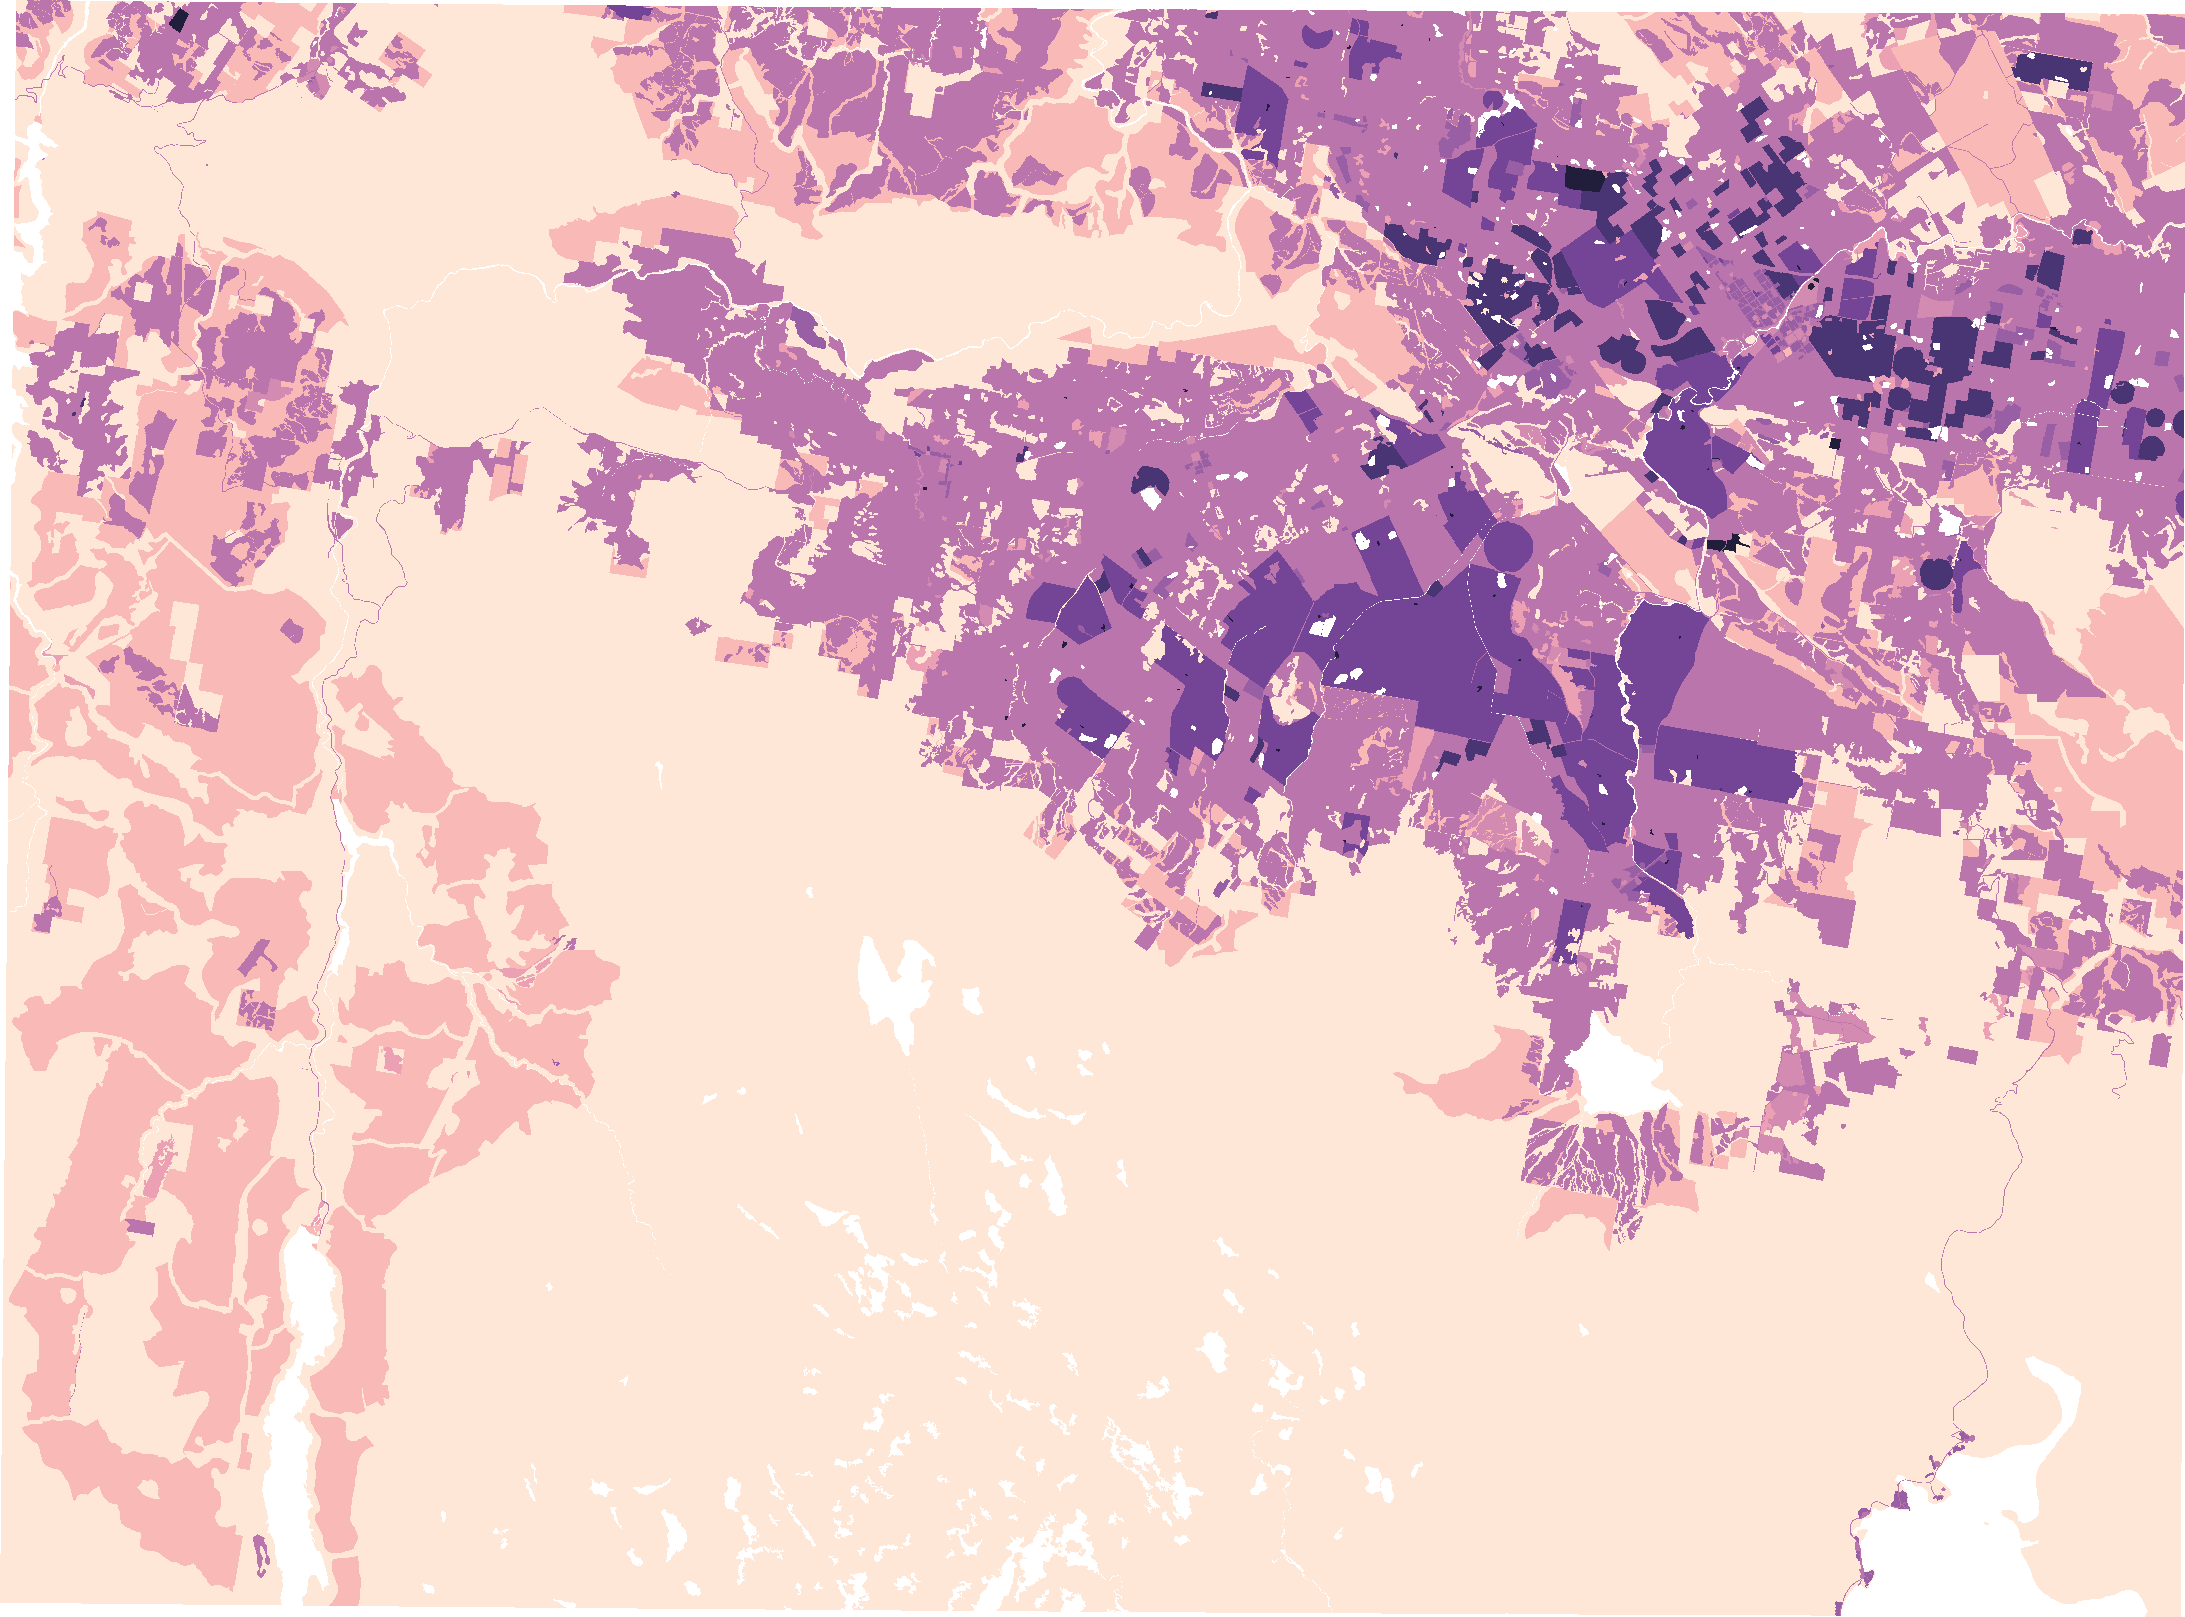

In [4]:
fig2

## Product against weighted sum, at Mole Creek

Drag the divider to compare the main map (susceptibility x connectivity x pressure x slope multiplied together) with the same four ingredients added with equal weights. The two maps are on different scales (the sum scores 0.4 to 0.6, the product mostly under 0.2), so each is split into fifths of its own karst cells: the colours show where each map ranks a cell, not how large its score is. Outlines are the Mole Creek karst.

In [5]:
from karst import aggregate_pressure_by_system, mole_creek_focus_mask
from hydro import slope_degrees, slope_risk_multiplier

# Mole Creek ingredients on the 25 m grid (the same layers as Stage 6)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; mc_tf = src.transform; mc_crs = src.crs; mc_bnds = src.bounds
    mc_w, mc_h = src.width, src.height
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    inten = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_mc_EPSG7855.tif") as src:
    conn = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    press = src.read(1).astype(float); press_nodata = src.nodata

karst_mc_all = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc_all = karst_mc_all[karst_mc_all.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus_mc = mole_creek_focus_mask(karst_mc_all, dem.shape, mc_tf)
valid_mc = (dem != dem_nodata) & focus_mc & (press != press_nodata)

S_mc, C_mc = inten / 4.0, conn / 3.0
P_mc = aggregate_pressure_by_system(karst_mc_all, press, mc_tf, press_nodata) / 3.0
m_mc = slope_risk_multiplier(slope_degrees(dem, dem_nodata, abs(mc_tf.a)))
slope_in = (m_mc - 0.5) / 0.5

risk_prod = np.where(valid_mc, S_mc * C_mc * P_mc * m_mc, np.nan)
risk_sum = np.where(valid_mc, np.where(S_mc > 0, (S_mc + C_mc + P_mc + slope_in) / 4.0, 0.0), np.nan)

FIFTH_LABELS = ["None", "Lowest fifth", "Second fifth", "Middle fifth", "Fourth fifth", "Highest fifth"]

def fifths(risk):
    """Classes 1-5 = fifths of this map's karst cells (0 off the karst, 255 outside the area)."""
    karst = valid_mc & (S_mc > 0) & np.isfinite(risk)
    cuts = np.quantile(risk[karst], [0.2, 0.4, 0.6, 0.8])
    cls = np.full(risk.shape, 255, dtype="uint8")
    cls[valid_mc] = 0
    cls[karst] = np.digitize(risk[karst], cuts, right=True) + 1
    return cls

def class_overlay(risk, name):
    """Risk raster in fifths of its own karst cells as a Web Mercator PNG (class colours as in the home-page map)."""
    cls, lab = fifths(risk), FIFTH_LABELS
    dst_tf, dw, dh = calculate_default_transform(mc_crs, "EPSG:3857", mc_w, mc_h, *mc_bnds)
    merc = np.full((dh, dw), 255, dtype="uint8")
    reproject(cls.astype("uint8"), merc, src_transform=mc_tf, src_crs=mc_crs, dst_transform=dst_tf, dst_crs="EPSG:3857",
              src_nodata=255, dst_nodata=255, resampling=Resampling.nearest)
    rgba = np.zeros((dh, dw, 4), dtype="uint8")
    for k in range(1, 6):
        rgba[merc == k] = [*(int(round(c * 255)) for c in RISK_COLOURS[k][:3]), 235]
    path = Path(tempfile.gettempdir()) / f"structure_{name}.png"
    Image.fromarray(rgba, "RGBA").save(path, optimize=True)
    west, south, east, north = transform_bounds("EPSG:3857", "EPSG:4326", *array_bounds(dh, dw, dst_tf))
    return path, [[south, west], [north, east]], cls, lab

png_prod, sbounds, cls_prod, lab_s = class_overlay(risk_prod, "product")
png_sum, _, cls_sum, _ = class_overlay(risk_sum, "sum")
karst_cells_mc = valid_mc & (S_mc > 0)
print("Cells per fifth, product:", [int((cls_prod == k).sum()) for k in range(1, 6)])
print("Cells per fifth, weighted sum:", [int((cls_sum == k).sum()) for k in range(1, 6)])

fig3 = folium.Figure(width="100%", height="400px")
m3 = folium.Map(tiles=None, control_scale=True, prefer_canvas=True).add_to(fig3)
folium.TileLayer("https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
                 attr="Tiles &copy; Esri", name="Esri World Topo", max_zoom=17).add_to(m3)
for name, z in [("pprod", 450), ("psum", 451), ("outline3", 460)]:
    folium.map.CustomPane(name, z_index=z, pointer_events=False).add_to(m3)
folium.raster_layers.ImageOverlay(image=str(png_prod), bounds=sbounds, interactive=False, pane="pprod").add_to(m3)
folium.raster_layers.ImageOverlay(image=str(png_sum), bounds=sbounds, interactive=False, pane="psum").add_to(m3)
folium.GeoJson(outline_json, style_function=lambda f: {"color": "#222222", "weight": 1.0, "fillOpacity": 0},
               interactive=False, pane="outline3").add_to(m3)
m3.fit_bounds([[kb[1] - 0.02, kb[0] - 0.02], [kb[3] + 0.02, kb[2] + 0.02]])

legend3 = ('<div style="position:absolute;bottom:34px;left:12px;z-index:1000;background:rgba(255,255,255,0.94);padding:6px 9px;'
           'border:1px solid #888;border-radius:4px;font:11px/1.3 Helvetica,Arial,sans-serif;box-shadow:0 1px 4px rgba(0,0,0,0.3)">'
           '<div style="font-weight:700;margin-bottom:4px">Rank within each map</div>'
           '<div style="display:flex">'
           + "".join(f'<span style="width:28px;height:12px;background:{hex_colour(RISK_COLOURS[k])};border:1px solid #777;margin-right:-1px"></span>' for k in range(1, 6))
           + '</div><div style="display:flex;justify-content:space-between;margin-top:2px;color:#444"><span>Lowest fifth</span><span>Highest fifth</span></div>'
           '<div style="margin-top:3px;color:#666">Outline: Mole Creek karst</div></div>')
m3.get_root().html.add_child(folium.Element(legend3))

js3 = f"""
window.addEventListener("load", function() {{
  var map = {m3.get_name()};
  var left = map.getPane("pprod"), right = map.getPane("psum");
  var frac = 0.5, dragging = false, box = map.getContainer();
  var div = document.createElement("div");
  div.style.cssText = "position:absolute;top:0;bottom:0;width:4px;margin-left:-2px;background:#fff;box-shadow:0 0 4px rgba(0,0,0,.6);z-index:1000;cursor:ew-resize;touch-action:none";
  div.innerHTML = '<div style="position:absolute;top:50%;left:50%;width:34px;height:34px;margin:-17px 0 0 -17px;border-radius:50%;background:#fff;border:2px solid #444;box-shadow:0 0 5px rgba(0,0,0,.5);font:bold 15px/30px Helvetica,Arial,sans-serif;text-align:center;color:#333">&#8596;</div>';
  box.appendChild(div);
  L.DomEvent.disableClickPropagation(div);
  function label(text, side) {{
    var d = document.createElement("div"); d.textContent = text;
    d.style.cssText = "position:absolute;top:10px;" + side + ":" + (side === "left" ? "58px" : "12px") + ";z-index:1000;background:rgba(255,255,255,.92);padding:3px 10px;border-radius:3px;font:700 14px Helvetica,Arial,sans-serif;box-shadow:0 1px 3px rgba(0,0,0,.4)";
    box.appendChild(d);
  }}
  label("Product (main)", "left"); label("Weighted sum", "right");
  function update() {{
    var size = map.getSize(), x = Math.round(frac * size.x);
    var nw = map.containerPointToLayerPoint([0, 0]), se = map.containerPointToLayerPoint(size), mid = map.containerPointToLayerPoint([x, 0]);
    left.style.clip = "rect(" + nw.y + "px," + mid.x + "px," + se.y + "px," + nw.x + "px)";
    right.style.clip = "rect(" + nw.y + "px," + se.x + "px," + se.y + "px," + mid.x + "px)";
    div.style.left = x + "px";
  }}
  function move(clientX) {{
    var r = box.getBoundingClientRect();
    frac = Math.min(1, Math.max(0, (clientX - r.left) / r.width)); update();
  }}
  div.addEventListener("mousedown", function(e) {{ dragging = true; map.dragging.disable(); e.preventDefault(); }});
  div.addEventListener("touchstart", function(e) {{ dragging = true; map.dragging.disable(); }}, {{passive: true}});
  document.addEventListener("mousemove", function(e) {{ if (dragging) move(e.clientX); }});
  document.addEventListener("touchmove", function(e) {{ if (dragging) move(e.touches[0].clientX); }}, {{passive: true}});
  function stop() {{ if (dragging) {{ dragging = false; map.dragging.enable(); }} }}
  document.addEventListener("mouseup", stop); document.addEventListener("touchend", stop);
  map.on("move zoom resize viewreset", update);
  update();
}});
"""
m3.get_root().script.add_child(folium.Element(js3))

Cells per fifth, product: [94697, 104833, 47972, 82501, 82501]
Cells per fifth, weighted sum: [82668, 105810, 59024, 82501, 82501]



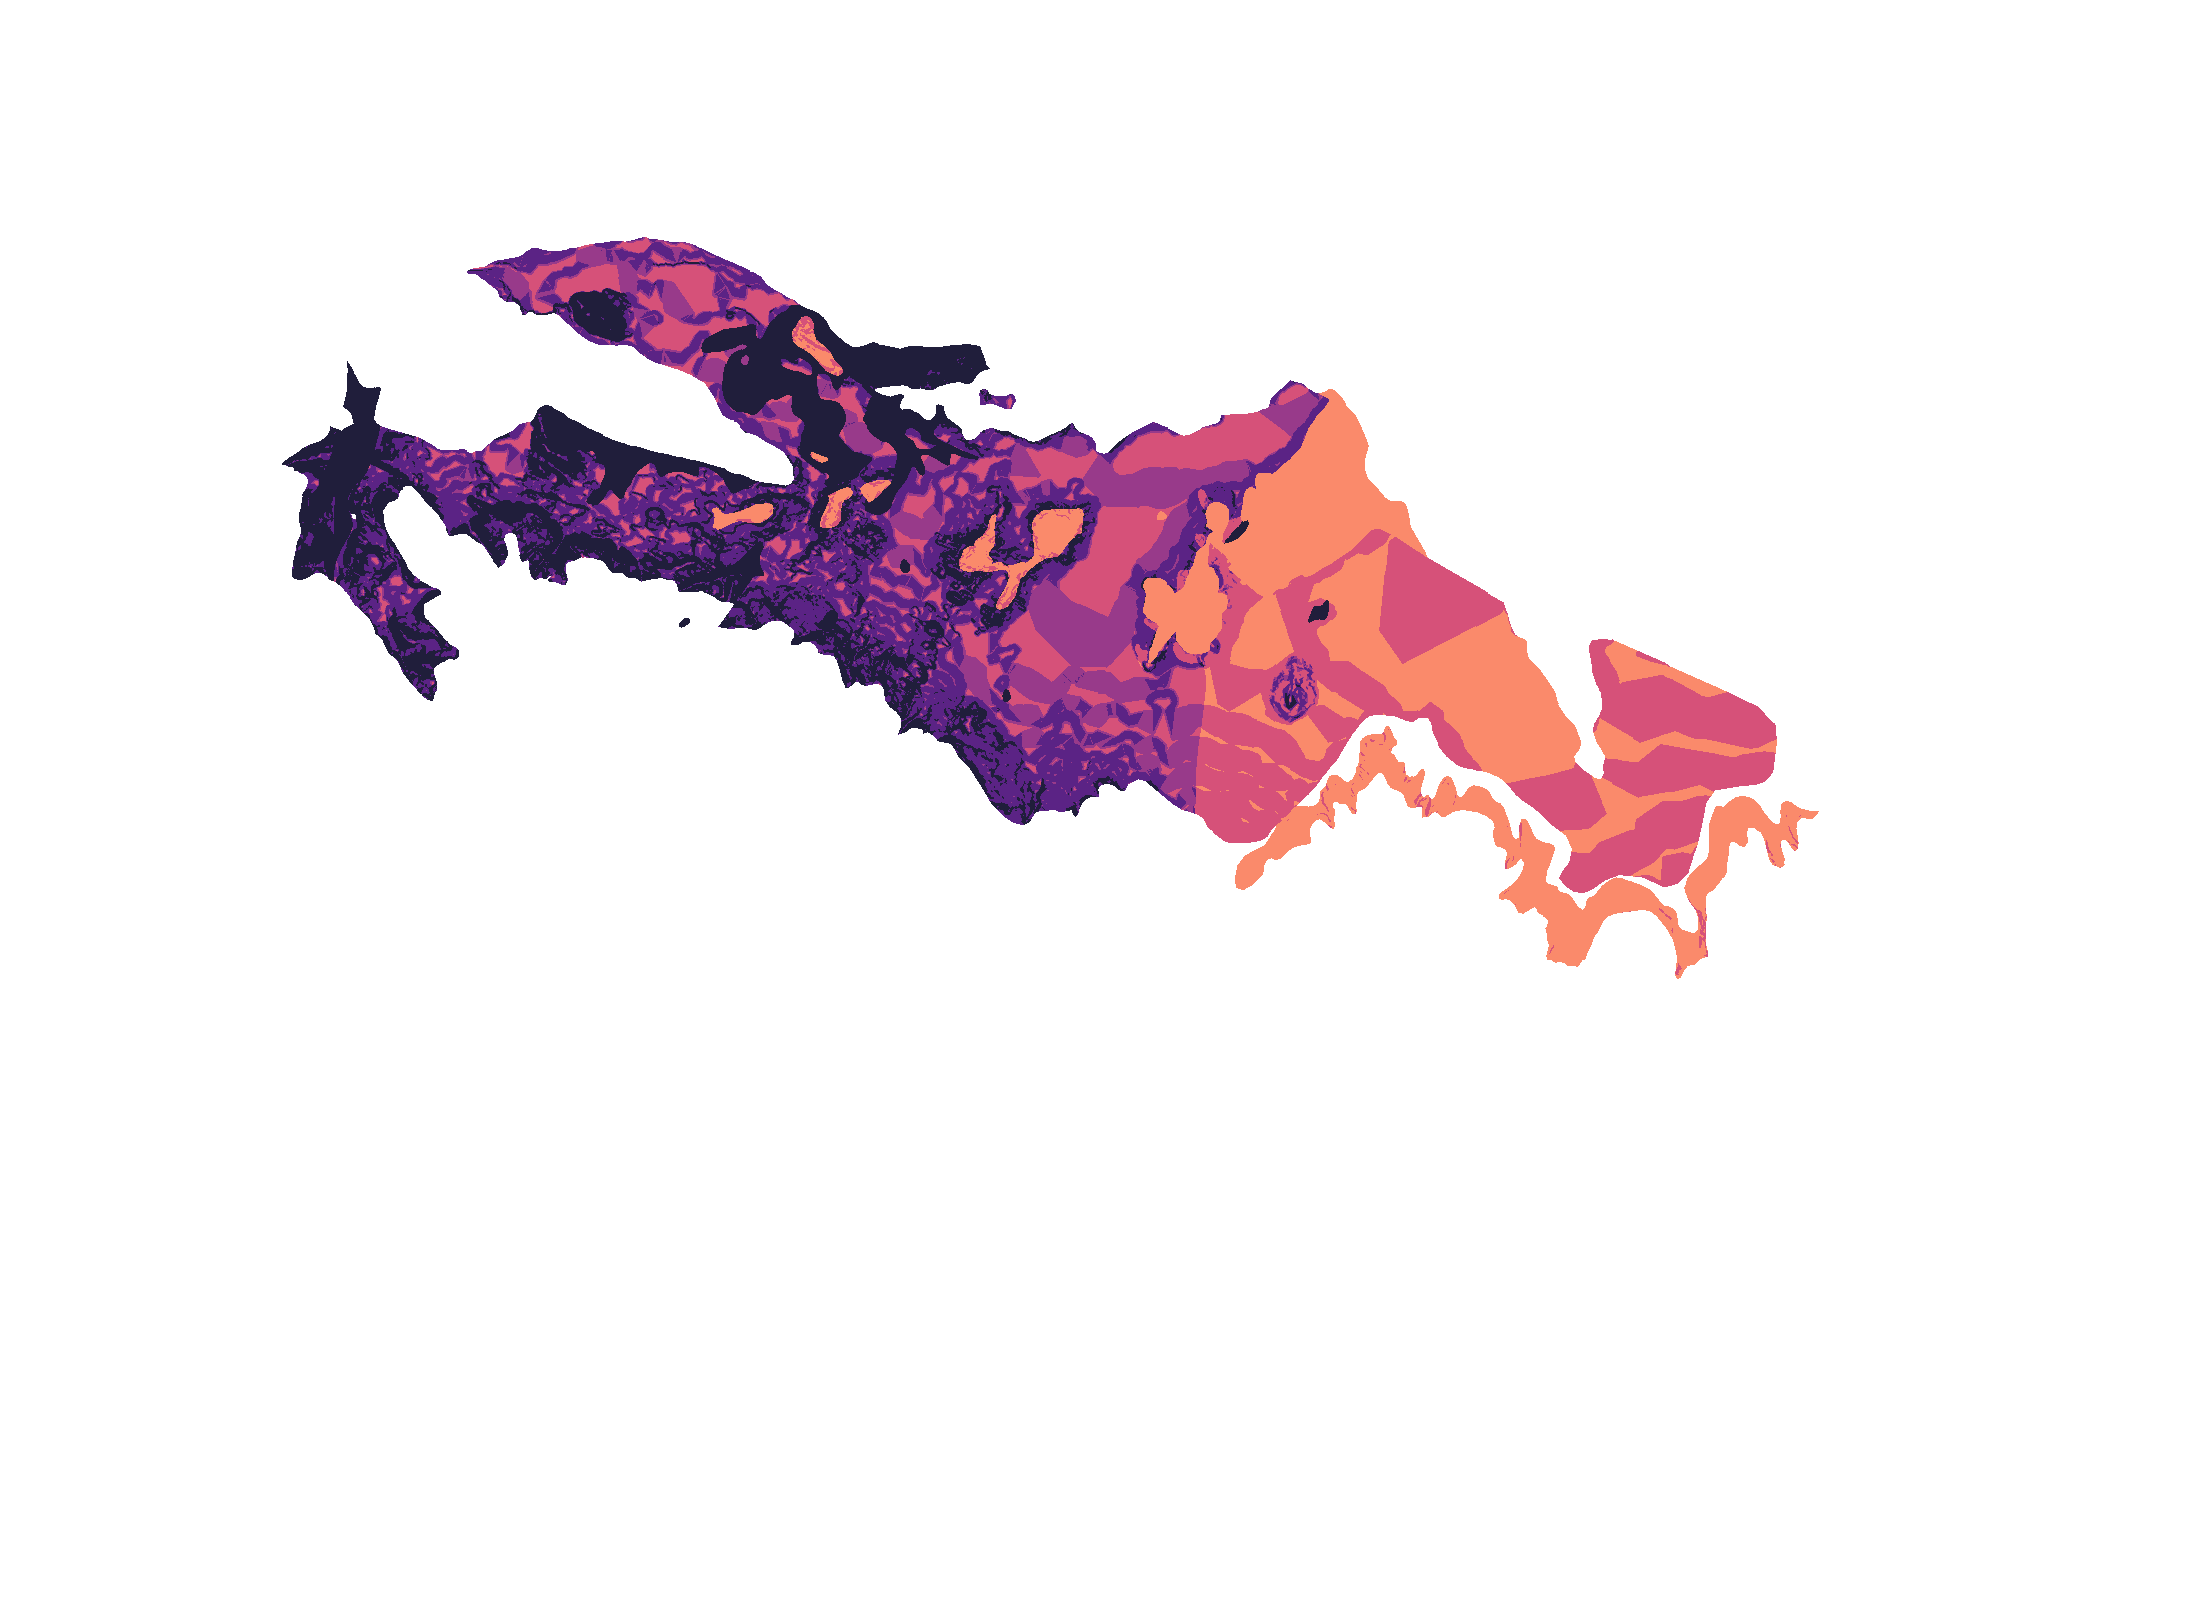
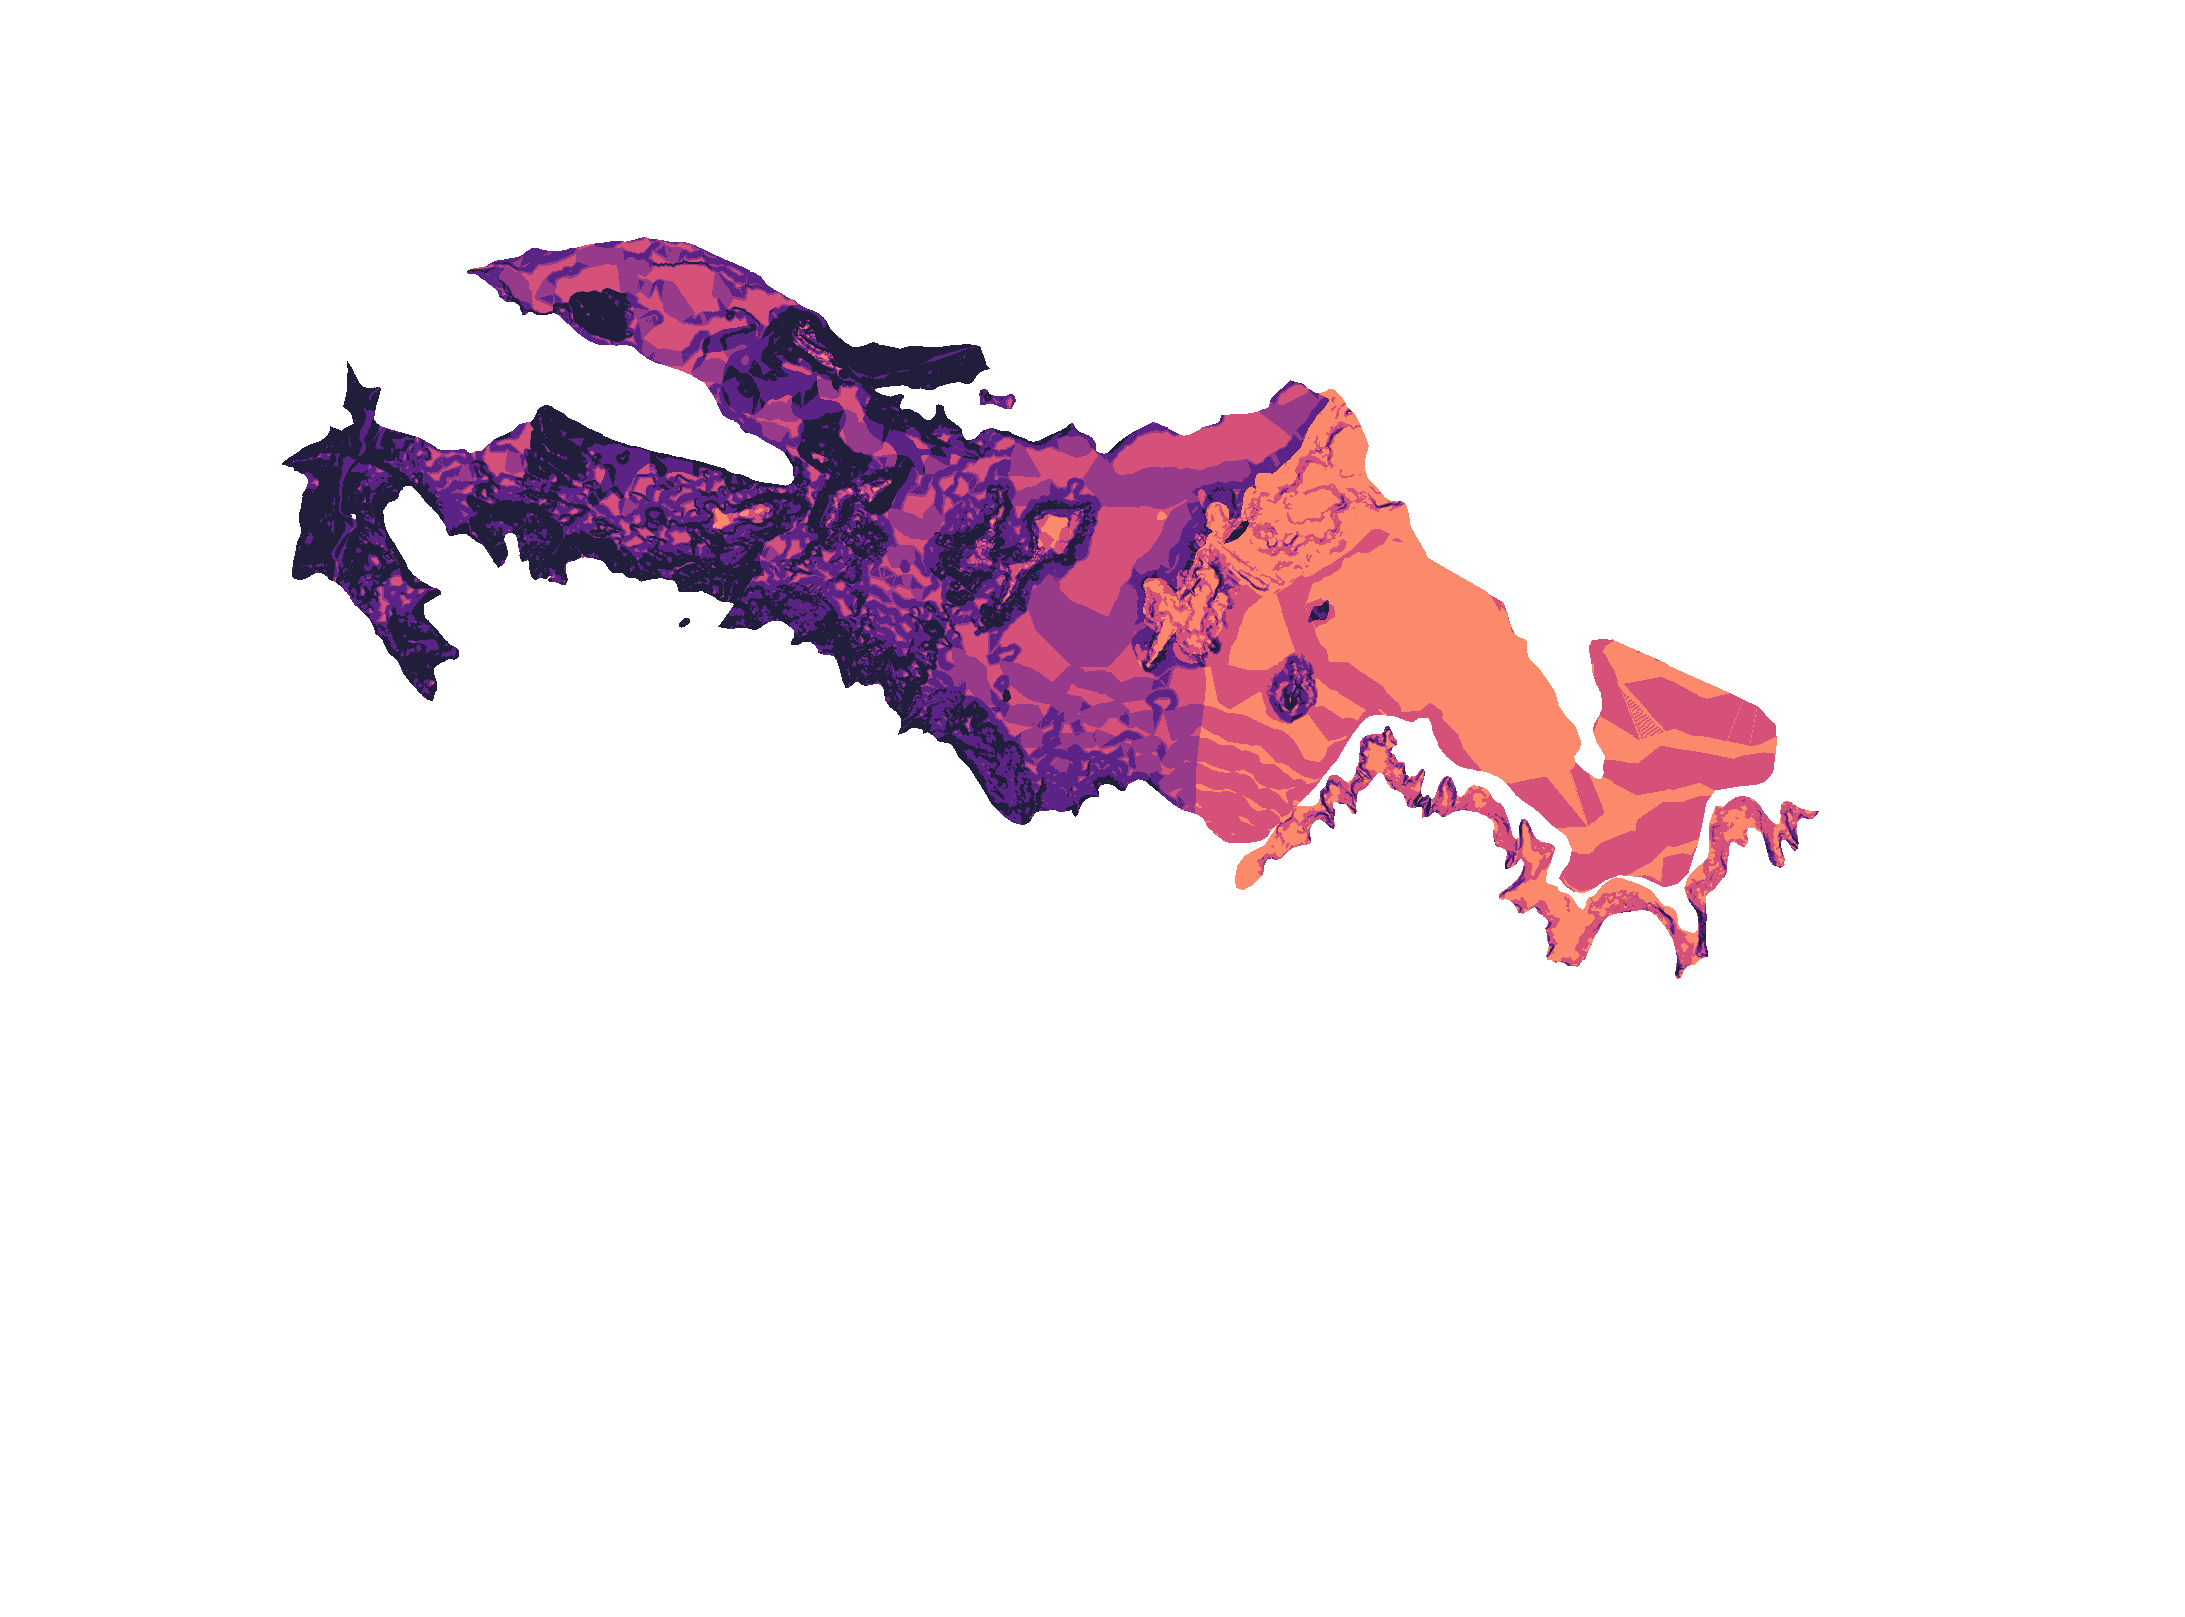

In [6]:
fig3